# Laboratorium 9:

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
%matplotlib inline


In [37]:
df = pd.read_excel('data.xlsx', engine='openpyxl')

print(f'Wczytano {len(df)} wierszy i {len(df.columns)} kolumn')
df.drop(df.columns[0], axis=1, inplace=True)
display(df.head())

X = df['X'].values.reshape(-1, 1)
y = df['Y'].values

print(f"X shape: {X.shape}, y shape: {y.shape}")

Wczytano 100 wierszy i 3 kolumn


,X,Y
0,-0.015981,0.001984
1,-0.012942,-0.000511
2,-0.018796,0.008553
3,-0.019340,-0.019842
4,0.015664,-0.002325


X shape: (100, 1), y shape: (100,)


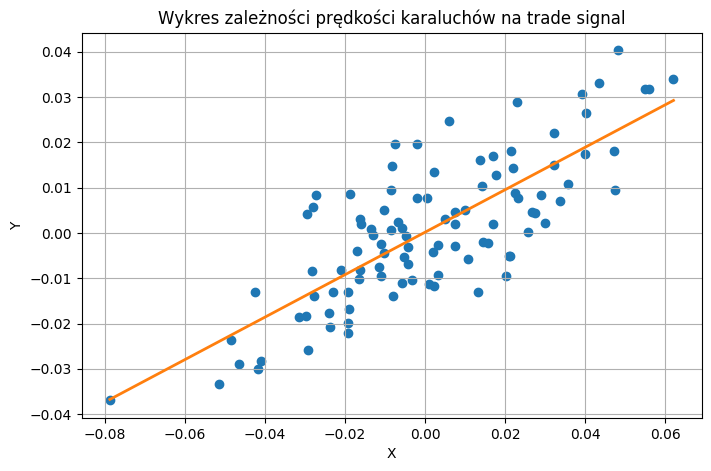

In [38]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
mse = mean_squared_error(y, y_pred)
sort_idx = X.ravel().argsort()
y_pred_sorted = y_pred[sort_idx]

plt.figure(figsize=(8,5))
plt.scatter(X.ravel(), y, c='C0')
plt.plot(X.ravel()[sort_idx], y_pred_sorted, c='C1', linewidth=2, )
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Wykres zależności prędkości karaluchów na trade signal')
plt.grid(True)
plt.show()


In [39]:
def stock_loss(factual, predicted, coef = 100.):
    if factual * predicted < 0:
        return coef * predicted**2 + abs(factual - predicted)
    else:
        return abs(factual - predicted)

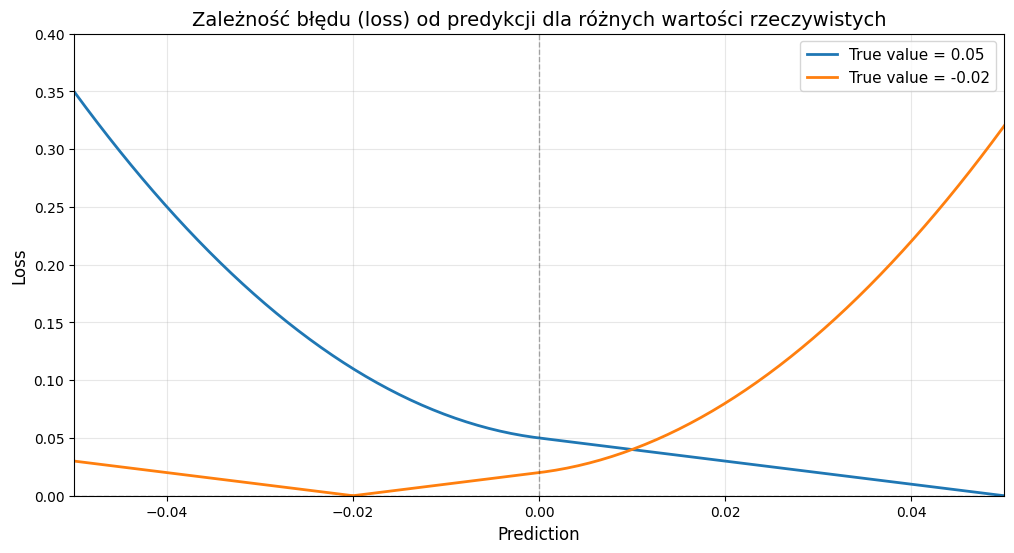

In [40]:
predictions = np.linspace(-0.1, 0.1, 500)

true_values = [0.05, -0.02]
colors = ['C0', 'C1']

plt.figure(figsize=(12, 6))

for true_val, color in zip(true_values, colors):
    losses_for_true_val = [stock_loss(true_val, pred) for pred in predictions]
    plt.plot(predictions, losses_for_true_val, label=f'True value = {true_val}', 
             linewidth=2, color=color)

plt.xlabel('Prediction', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Zależność błędu (loss) od predykcji dla różnych wartości rzeczywistych', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
plt.xlim(-0.05, 0.05)
plt.ylim(0, 0.4)
plt.show()


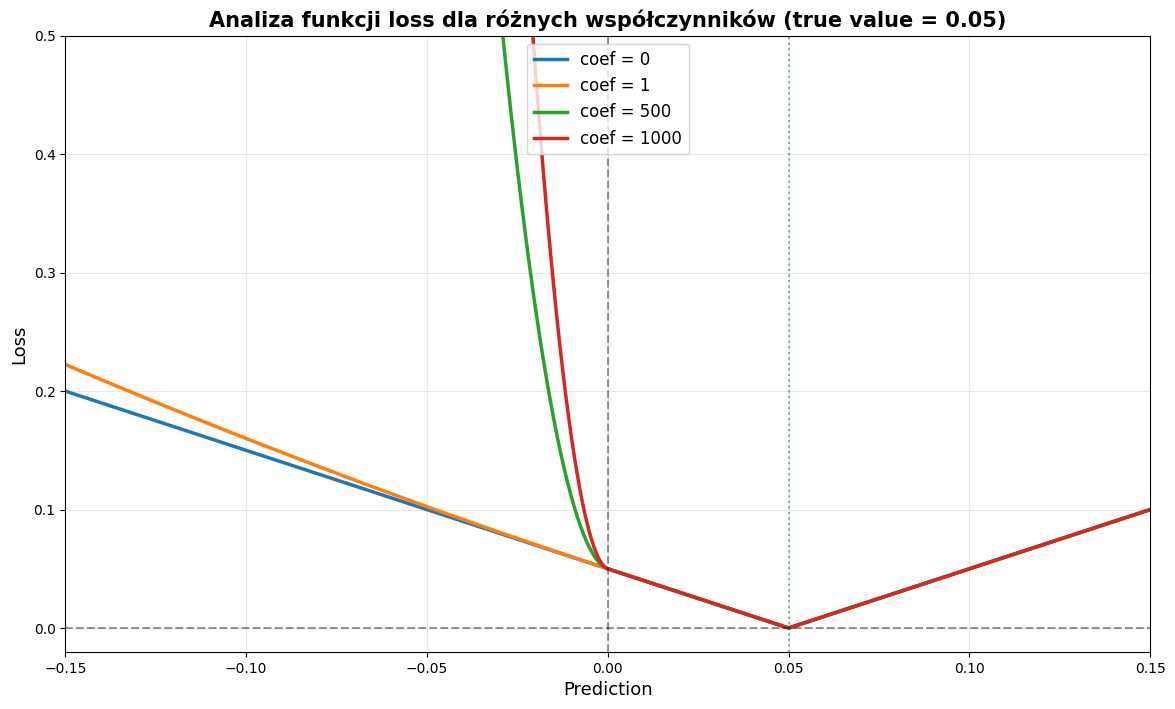

In [ ]:
predictions = np.linspace(-0.2, 0.2, 500)
coef_values = [0, 1, 500, 1000]
true_value = 0.05

plt.figure(figsize=(14, 8))

for coef in coef_values:
    losses = []
    for pred in predictions:
        if true_value * pred < 0:
            loss = coef * pred**2 + abs(true_value - pred)
        else:
            loss = abs(true_value - pred)
        losses.append(loss)
    
    plt.plot(predictions, losses, label=f'coef = {coef}', linewidth=2.5)

plt.xlabel('Prediction', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.title(f'Analiza funkcji loss dla różnych współczynników (true value = {true_value})', 
          fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc='upper center')
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.4, linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.4, linewidth=1.5)
plt.axvline(x=true_value, color='green', linestyle=':', alpha=0.5, linewidth=1.5, label=f'True value = {true_value}')
plt.xlim(-0.15, 0.15)
plt.ylim(-0.02, 0.5)
plt.show()

Współczynnik coeff wpływa jedynie na wartości przeciwne znakiem (czyli konkretną pomyłkę ruchu podjętego na rynku). Uwypukla dodatkowo wagę tego błędu, im wieksza pomyłka tym większa strata.